## Desarrollo tarea HW Sesión 4

Felipe López Vergara

## 1. Simulación

Suponga un proceso $\epsilon_t$ con media cero y varianza igual a 3. Se sabe que, $\mathbb{E}(y_t) = 10$ y condición inicial es $y_1 = 9$ y $y_2 = 10.3$. Simule, recursivamente, 100 periodos para la variable $y_t$ para los siguientes modelos.

In [1]:
from matplotlib import pyplot as plt 
from scipy.stats import lognorm
import statsmodels.api as sm
import pandas as pd 
import seaborn as sns
import yfinance as yf
import numpy as np


sns.set_style("dark")

*AR(1) con $\phi_1 = 0,4$, $\phi_1 = 0,8$ y $\phi_1 = 0,99$

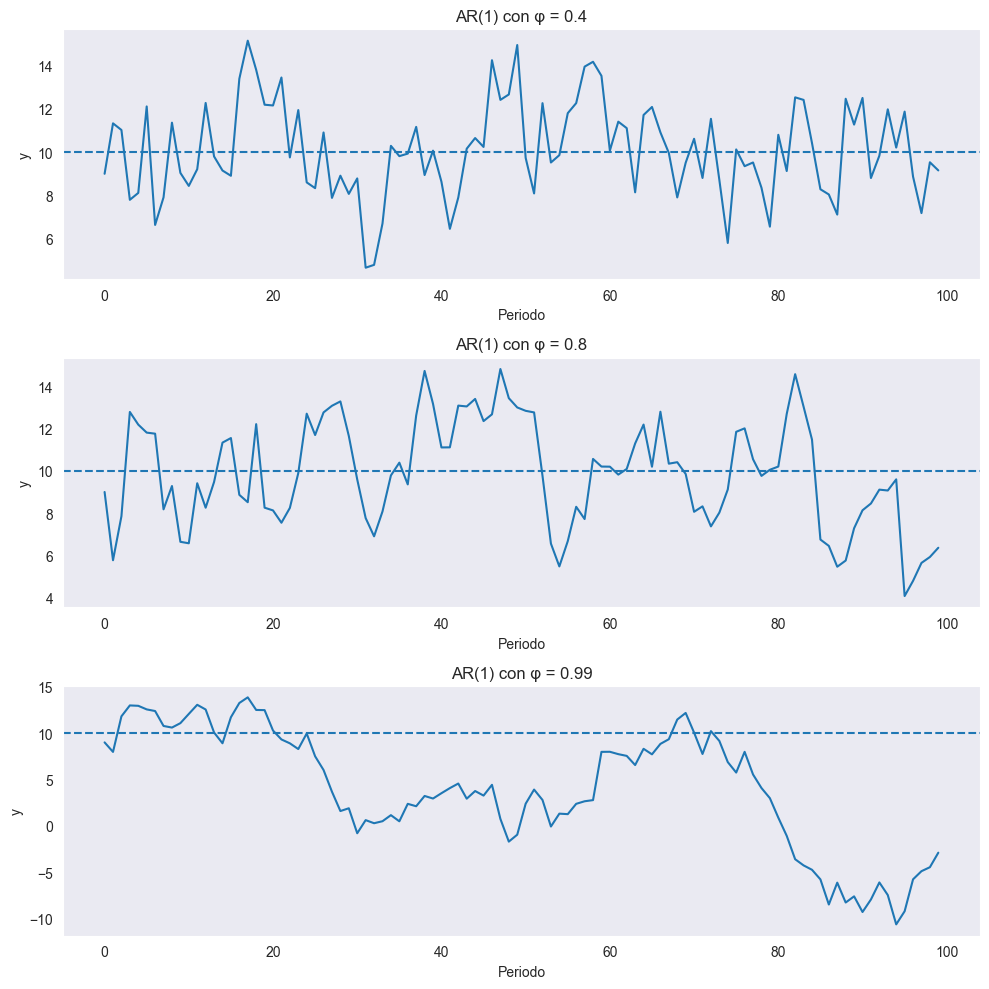

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess

# Fijar semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi
phis = [0.4, 0.8, 0.99]

# Crear una figura
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi in enumerate(phis):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9

    # Simulación recursiva
    for t in range(1, T):
        y[t] = mu + phi*(y[t-1] - mu) + e[t]

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, linestyle='--')
    ax[i].set_title(f'AR(1) con φ = {phi}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*AR(2) con $\phi_1 = 0,2$, $\phi_1 = 0,4$ y $\phi_1 = 0,8$ y $\phi_2 = -0,05$

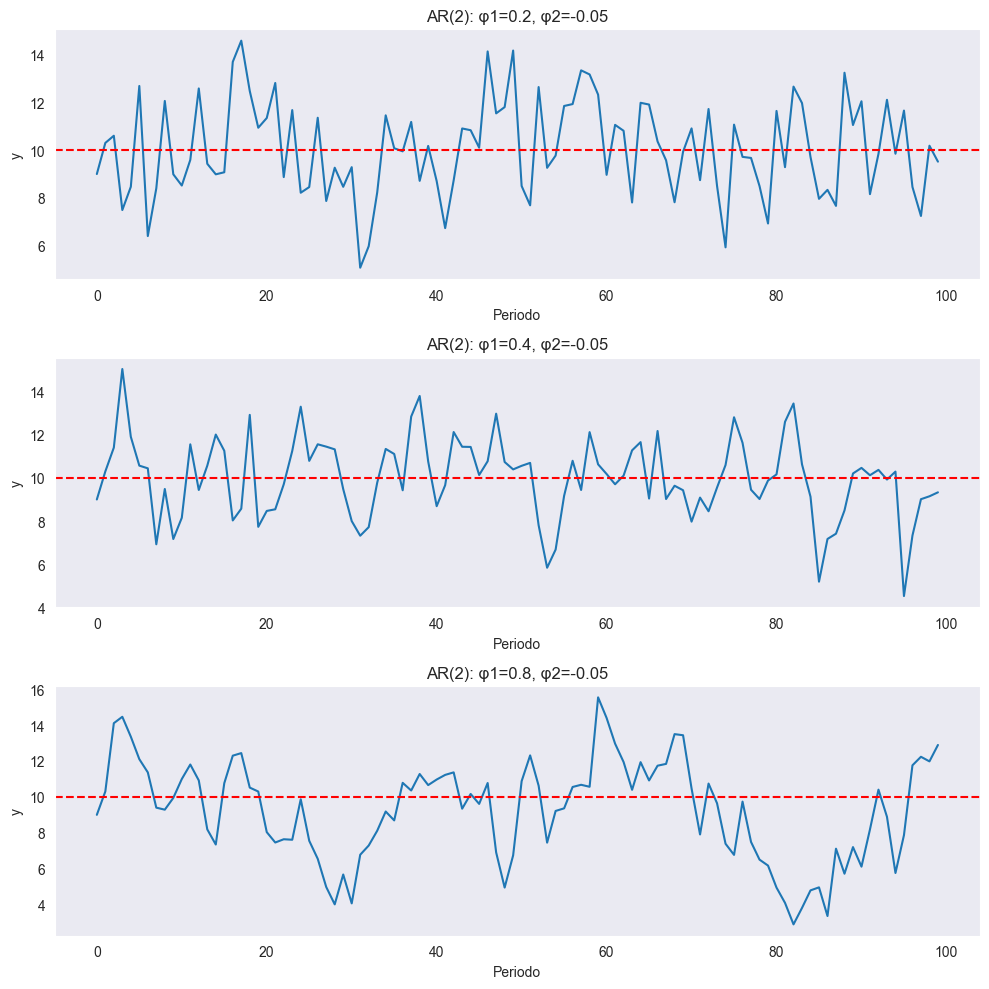

In [3]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de phi1
phi1_vals = [0.2, 0.4, 0.8]
phi2 = -0.05

# DataFrame para guardar las simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Crear gráficos
fig, ax = plt.subplots(3, 1, figsize=(10, 10))

for i, phi1 in enumerate(phi1_vals):

    # Generar errores
    e = np.random.normal(0, sigma, T)

    # Inicializar la serie
    y = np.zeros(T)
    y[0] = 9
    y[1] = 10.3

    # Simulación recursiva
    for t in range(2, T):
        y[t] = (mu
                + phi1*(y[t-1] - mu)
                + phi2*(y[t-2] - mu)
                + e[t])

    # Guardar resultados
    simulaciones[f'AR2_phi1_{phi1}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'AR(2): φ1={phi1}, φ2={phi2}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*MA(1) con $\theta_1 = 0.5$ y $\theta_1 = 2$

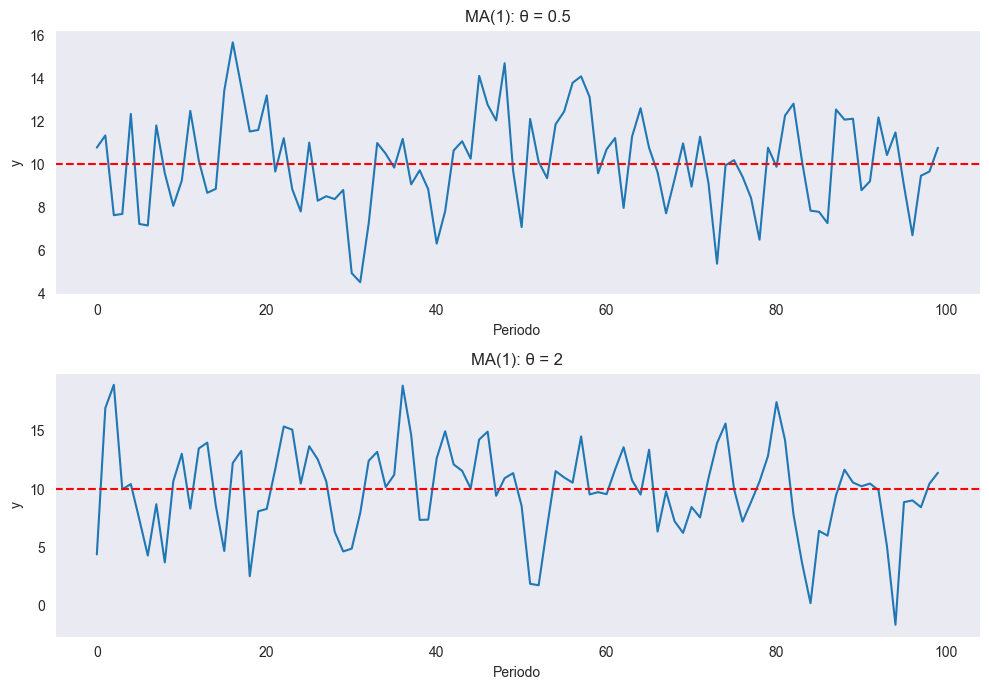

In [4]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
sigma = np.sqrt(3)

# Valores de theta
thetas = [0.5, 2]

# DataFrame para guardar simulaciones
simulaciones = pd.DataFrame(index=range(1, T+1))

# Generar gráficos
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

for i, theta in enumerate(thetas):

    # Generar errores
    e = np.random.normal(0, sigma, T + 1)

    # Inicializar serie
    y = np.zeros(T)

    # Simulación recursiva
    for t in range(T):
        y[t] = mu + e[t+1] + theta * e[t]

    # Guardar resultados
    simulaciones[f'MA1_theta_{theta}'] = y

    # Graficar
    ax[i].plot(y)
    ax[i].axhline(mu, color='red', linestyle='--')
    ax[i].set_title(f'MA(1): θ = {theta}')
    ax[i].set_xlabel('Periodo')
    ax[i].set_ylabel('y')

plt.tight_layout()
plt.show()

*ARMA(1,1) con $\phi_1 = 0,4$ y $\theta_1 = 0,5$

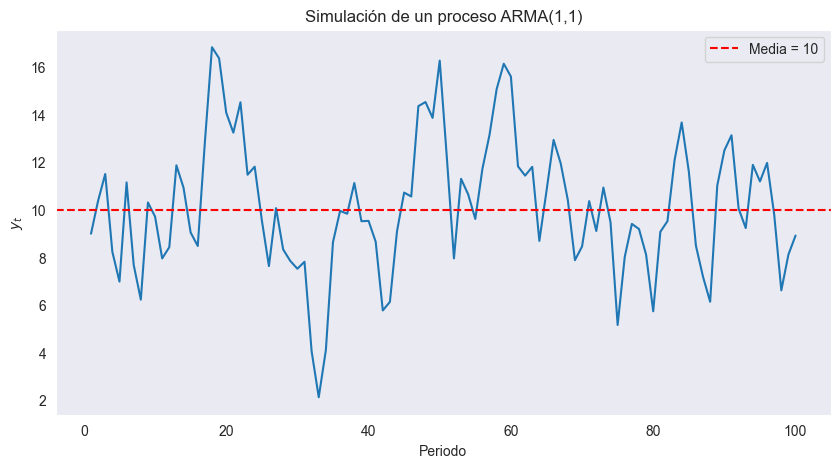

In [5]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
phi = 0.4
theta = 0.5
sigma = np.sqrt(3)

# Generar errores
e = np.random.normal(0, sigma, T + 1)

# Inicializar la serie
y = np.zeros(T)
y[0] = 9

# Simulación recursiva
for t in range(1, T):
    y[t] = (mu
            + phi*(y[t-1] - mu)
            + e[t]
            + theta*e[t-1])

# Guardar en DataFrame
df = pd.DataFrame({
    'Periodo': np.arange(1, T+1),
    'ARMA(1,1)': y
})

# Graficar
plt.figure(figsize=(10,5))
plt.plot(df['Periodo'], df['ARMA(1,1)'])
plt.axhline(mu, color='red', linestyle='--', label='Media = 10')
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación de un proceso ARMA(1,1)')
plt.legend()
plt.show()

*ARMA(2,1) con $\phi_1 = 0,4$, $\phi_2 = -0.2$ y $\theta_1 = 0,5$

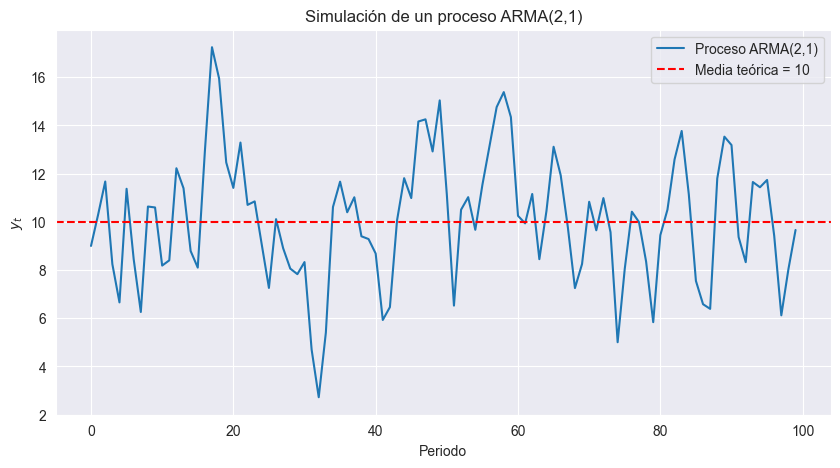

In [6]:
# Semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
phi1 = 0.4
phi2 = -0.2
theta1 = 0.5
sigma = np.sqrt(3)

# Constante
c = mu * (1 - phi1 - phi2)

# Vectores
y = np.zeros(T)
eps = np.random.normal(0, sigma, T)

# Condiciones iniciales
y[0] = 9
y[1] = 10.3

# Suponemos epsilon_0 = 0
eps_lag = 0

# Simulación recursiva
for t in range(2, T):
    y[t] = (c
            + phi1 * y[t-1]
            + phi2 * y[t-2]
            + eps[t]
            + theta1 * eps[t-1])

# Graficar
plt.figure(figsize=(10,5))
plt.plot(y, label='Proceso ARMA(2,1)')
plt.axhline(mu, color='red', linestyle='--',
            label='Media teórica = 10')
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación de un proceso ARMA(2,1)')
plt.legend()
plt.grid(True)
plt.show()

* **ARMA(2,2)** con $\phi_1 = 0,4$, $\phi_2 = -0.2$, $\theta_1 = 0.5$ y $\theta_2 = 0.3$ *(requerido para Ejercicio 2)*

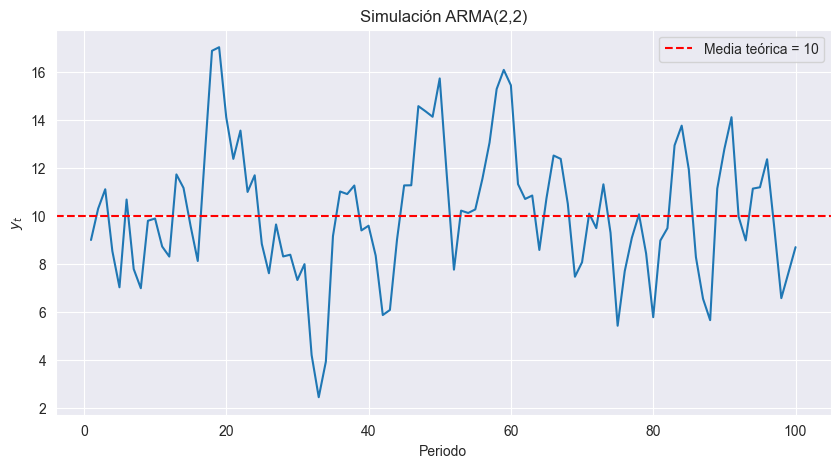

In [7]:
# Fijar semilla para reproducibilidad
np.random.seed(123)

# Parámetros
T = 100
mu = 10
phi1 = 0.4
phi2 = -0.2
theta1 = 0.5
theta2 = 0.3
sigma = np.sqrt(3)

# Constante
c = mu * (1 - phi1 - phi2)

# Vectores
y = np.zeros(T)
eps = np.random.normal(0, sigma, T)

# Condiciones iniciales
y[0] = 9
y[1] = 10.3

# Suponemos ε0 = ε−1 = 0
eps_m1 = 0
eps_m2 = 0

# Simulación recursiva
for t in range(2, T):

    e1 = eps[t-1] if t-1 >= 0 else 0
    e2 = eps[t-2] if t-2 >= 0 else 0

    y[t] = (
        c
        + phi1 * y[t-1]
        + phi2 * y[t-2]
        + eps[t]
        + theta1 * e1
        + theta2 * e2
    )

# Graficar
plt.figure(figsize=(10,5))
plt.plot(range(1, T+1), y)
plt.axhline(mu, color='red',
            linestyle='--',
            label='Media teórica = 10')
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación ARMA(2,2)')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
from statsmodels.tsa.arima_process import ArmaProcess
import numpy as np

np.random.seed(123)

ar = np.array([1, -0.4, 0.2])
ma = np.array([1, 0.5, 0.3])

arma = ArmaProcess(ar, ma)

y = arma.generate_sample(
    nsample=100,
    scale=np.sqrt(3)
) + 10

*ARIMA(2,1,1) con $\phi_1 = 0,4$, $\phi_2 = -0.2$ y $\theta_1 = 0,5$

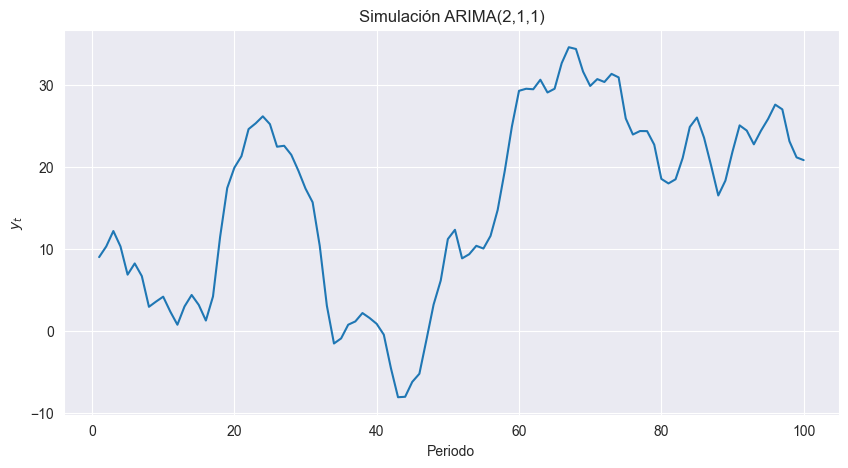

In [9]:
# Semilla
np.random.seed(123)

# Parámetros
T = 100
phi1 = 0.4
phi2 = -0.2
theta1 = 0.5
sigma = np.sqrt(3)

# Errores
eps = np.random.normal(0, sigma, T)

# Serie original y diferencias
y = np.zeros(T)
dy = np.zeros(T)

# Condiciones iniciales
y[0] = 9
y[1] = 10.3

# Diferencia inicial
dy[1] = y[1] - y[0]

# Suponemos Δy0 = 0 y ε0 = 0
dy[0] = 0

# Simulación recursiva
for t in range(2, T):

    dy[t] = (
        phi1 * dy[t-1]
        + phi2 * dy[t-2]
        + eps[t]
        + theta1 * eps[t-1]
    )

    # Integrar para obtener y_t
    y[t] = y[t-1] + dy[t]

# Graficar
plt.figure(figsize=(10,5))
plt.plot(range(1, T+1), y)
plt.xlabel('Periodo')
plt.ylabel('$y_t$')
plt.title('Simulación ARIMA(2,1,1)')
plt.grid(True)
plt.show()

## 2. Estimación por Máxima Verosimilitud de un ARMA(2,2)

Considere el modelo ARMA(2,2) con constante:

$$y_t=\mu+\phi_1y_{t-1}+\phi_2y_{t-2}+\varepsilon_t+\theta_1\varepsilon_{t-1}+\theta_2\varepsilon_{t-2},$$

con vector de parámetros $\boldsymbol{\psi} = (\mu,\,phi_1,\,\phi_2,\,\theta_1,\,\theta_2,\,\sigma^2)^\top$.


## 2.1 Derivación de la Log-Verosimilitud Condicional

Condicione en las primeras dos observaciones y fije $\hat{\varepsilon}_1=\hat{\varepsilon}_2=0.$

$(a)$ Muestre que los residuos se recuperan de forma recursiva:

$$\varepsilon_t=y_t-\mu-\phi_1y_{t-1}-\phi_2y_{t-2}-\theta_1\varepsilon_{t-1}-\theta_2\varepsilon_{t-2}. \qquad t = 3,\ldots,T$$

El modelo ARMA(2,2) con constante es

$$y_t=\mu+\phi_1y_{t-1}+\phi_2y_{t-2}+\varepsilon_t+\theta_1\varepsilon_{t-1}+\theta_2\varepsilon_{t-2},$$

donde

$$\varepsilon_t\sim\mathcal{N}(0,\sigma^2).$$


Despejando el término de error,

$$\varepsilon_t=y_t-\mu-\phi_1y_{t-1}-\phi_2y_{t-2}-\theta_1\varepsilon_{t-1}-\theta_2\varepsilon_{t-2}.$$

Como los errores verdaderos no son observables, se reemplazan por sus estimaciones recursivas:

$$\hat{\varepsilon}_t=y_t-\mu-\phi_1y_{t-1}-\phi_2y_{t-2}-\theta_1\hat{\varepsilon}_{t-1}-\theta_2\hat{\varepsilon}_{t-2},\qquad t=3,\ldots,T.$$

Para iniciar la recursión se fijan las condiciones iniciales

$$\hat{\varepsilon}_1=\hat{\varepsilon}_2=0.$$

Así,

$$\hat{\varepsilon}_3=y_3-\mu-\phi_1y_2-\phi_2y_1,$$

$$\hat{\varepsilon}_4=y_4-\mu-\phi_1y_3-\phi_2y_2-\theta_1\hat{\varepsilon}_3,$$

$$\hat{\varepsilon}_5=y_5-\mu-\phi_1y_4-\phi_2y_3-\theta_1\hat{\varepsilon}_4-\theta_2\hat{\varepsilon}_3,$$

y así sucesivamente hasta \(t=T\).

Por lo tanto, los residuos pueden calcularse recursivamente utilizando las observaciones pasadas y los residuos previamente obtenidos.

$(b)$ Usando que $$\varepsilon_t \mid \mathcal{F}_{t-1}\sim\mathcal{N}(0,\sigma^2),$$ derive la log-verosimilitud condicional:

$$\ell(\boldsymbol{\psi}\mid\mathbf{y})=-\frac{T^*}{2}\ln(2\pi\sigma^2)-\frac{1}{2\sigma^2}\sum_{t=3}^{T}\hat{\varepsilon}_t^{\,2}, T^*=T-2.$$

Bajo el supuesto

$$\varepsilon_t \mid \mathcal{F}_{t-1}\sim\mathcal{N}(0,\sigma^2),$$

cada residuo condicional tiene densidad

$$f(\varepsilon_t)=\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{\varepsilon_t^2}{2\sigma^2}\right).$$

Como en la verosimilitud condicional se comienza en \(t=3\), la función de verosimilitud es

$$L(\boldsymbol{\psi}\mid\mathbf{y})=\prod_{t=3}^{T}\frac{1}{\sqrt{2\pi\sigma^2}}\exp\!\left(-\frac{\hat{\varepsilon}_t^{\,2}}{2\sigma^2}\right).$$

Separando los factores,

$$L(\boldsymbol{\psi}\mid\mathbf{y})=(2\pi\sigma^2)^{-T^*/2}\exp\!\left(-\frac{1}{2\sigma^2}\sum_{t=3}^{T}\hat{\varepsilon}_t^{\,2}\right),$$

donde 
$$T^*=T-2.$$

Aplicando logaritmo natural,

$$\ell(\boldsymbol{\psi}\mid\mathbf{y})=\ln L(\boldsymbol{\psi}\mid\mathbf{y}),$$

se obtiene

$$\ell(\boldsymbol{\psi}\mid\mathbf{y})=-\frac{T^*}{2}\ln(2\pi\sigma^2)-\frac{1}{2\sigma^2}\sum_{t=3}^{T}\hat{\varepsilon}_t^{\,2}$$

Finalmente,

$$\ell(\boldsymbol{\psi}\mid\mathbf{y})=-\frac{T^*}{2}\ln(2\pi\sigma^2)-\frac{1}{2\sigma^2}\sum_{t=3}^{T}\hat{\varepsilon}_t^{\,2}, T^*=T-2.$$

Esta es la expresión de la log-verosimilitud condicional utilizada para estimar los parámetros

$$\boldsymbol{\psi}=\left(\mu,\phi_1,\phi_2,\theta_1,\theta_2,\sigma^2\right)^\top$$

mediante máxima verosimilitud.

La estimación consiste en encontrar el vector

$$\hat{\boldsymbol{\psi}}=\arg\max_{\boldsymbol{\psi}}\ell(\boldsymbol{\psi}\mid\mathbf{y}),$$

lo cual equivale a minimizar la suma de cuadrados de los residuos recursivos cuando \(\sigma^2\) también se estima.

$(c)$ ¿Por qué no es posible evaluar la verosimilitud para $t=1,2$ sin información adicional? ¿Qué supone la verosimilitud exacta en lugar de la condicional?

No es posible evaluar la verosimilitud para $t=1 y t=2$ porque el modelo ARMA(2,2) requiere conocer observaciones y errores de períodos anteriores. En particular, el cálculo recursivo de los residuos

$$\varepsilon_t=y_t-\mu-\phi_1y_{t-1}-\phi_2y_{t-2}-\theta_1\varepsilon_{t-1}-\theta_2\varepsilon_{t-2}.$$

necesita los valores de $\y_{t-1}, \y_{t-2},\varepsilon_{t-1} y \varepsilon_{t-2}$ Para t=1 y t=2, algunos de estos términos corresponden a períodos anteriores al inicio de la muestra y, por lo tanto, son desconocidos.

Por esta razón, la verosimilitud condicional fija condiciones iniciales, típicamente 
$$\hat{\varepsilon}_1=\hat{\varepsilon}_2=0.$$

y comienza la evaluación de la función de verosimilitud desde $t=3$. De esta forma, se condiciona la inferencia a los valores iniciales elegidos.

La verosimilitud exacta no fija condiciones iniciales, sino que asume un proceso estacionario e invertible e incorpora la distribución conjunta de las observaciones y errores iniciales. De este modo utiliza toda la información disponible desde \(t=1\), obteniendo estimadores más eficientes, especialmente en muestras pequeñas, aunque con un mayor costo computacional.

## 2.2 Implementación en Python

Use la serie **ARMA(2,2)** simulada en el Ejercicio 1 ($\phi_1=0.4$, $\phi_2=-0.2$, $\theta_1=0.5$, $\theta_2=0.3$, $\mu=10$, $\sigma^2=3$).

**(a)** Implemente la función `compute_residuals(psi, y)` que recupera $\hat{\varepsilon}_t$ recursivamente dado $\boldsymbol{\psi}$ e $\mathbf{y}$.

In [52]:
# Fijar semilla para reproducibilidad
np.random.seed(42)
y_true = np.zeros(100)
errors = np.random.normal(0, np.sqrt(3), 100)
for t in range(2, 100):
    y_true[t] = 10 + 0.4*(y_true[t-1]-10) - 0.2*(y_true[t-2]-10) + errors[t] + 0.5*errors[t-1] + 0.3*errors[t-2]



# Definición de la función compute_residuals
def compute_residuals(psi, y):
    """
    Recupera los residuos epsilon_t de forma recursiva.
    psi = [phi1, phi2, theta1, theta2, mu, sigma2]
    """
    phi1, phi2, theta1, theta2, mu, _ = psi
    N = len(y)
    epsilon = np.zeros(N)
    
    # Asumimos condiciones iniciales de los residuos pasados igual a 0 (epsilon_1 = epsilon_0 = 0)
    # Empezamos la recursión desde t = 2
    for t in range(2, N):
        epsilon[t] = (y[t] - mu) - phi1 * (y[t-1] - mu) - phi2 * (y[t-2] - mu) - theta1 * epsilon[t-1] - theta2 * epsilon[t-2]
        
    return epsilon

**(b)** Implemente la función `neg_log_likelihood(psi, y)` que retorna $-\log L(\boldsymbol{\psi}\mid\mathbf{y})$

In [53]:
# Definición de la función neg_log_likelihood
def neg_log_likelihood(psi, y):
    """
    Retorna el log-likelihood negativo condicional -l(psi | y)
    """
    sigma2 = psi[5]
    
    # Restricción matemática: varianza no puede ser negativa o cero
    if sigma2 <= 0:
        return np.inf
        
    epsilon = compute_residuals(psi, y)
    
    # Evaluamos a partir de t = 2 debido a las pérdidas de condiciones iniciales
    epsilon_cond = epsilon[2:]
    N_cond = len(epsilon_cond)
    
    # Fórmula de la Log-Verosimilitud Gaussiana Condicional
    log_likelihood = - (N_cond / 2) * np.log(2 * np.pi) - (N_cond / 2) * np.log(sigma2) - (1 / (2 * sigma2)) * np.sum(epsilon_cond**2)
    
    return -log_likelihood

**(c)** Minimice `neg_log_likelihood` usando `scipy.optimize.minimize` con el método `L-BFGS-B`. Utilice como punto inicial $\boldsymbol{\psi}_0 = (0,0,0,0,0,1)^\top$

In [54]:
from scipy.optimize import minimize

# Punto inicial para la optimización (psi_0)
psi_0 = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 1.0])

# Definimos límites (bounds) opcionales para evitar que sigma^2 decaiga a valores <= 0
bounds = [(-0.99, 0.99), (-0.99, 0.99), (-0.99, 0.99), (-0.99, 0.99), (None, None), (1e-6, None)]

resultado = minimize(
    fun=neg_log_likelihood,
    x0=psi_0,
    args=(y_true,), # Pasamos nuestra serie de tiempo 'y'
    method='L-BFGS-B',
    bounds=bounds
)

**(d)** Reporte $\boldsymbol{\psi}$ y compárelo con los parámetros verdaderos de la simulación.

In [55]:
# Reportar psi_hat y comparar con los parámetros verdaderos
psi_hat = resultado.x
parametros_verdaderos = [0.4, -0.2, 0.5, 0.3, 10.0, 3.0]

print("## --- RESULTADOS DE LA OPTIMIZACIÓN --- ##\n")
print(f"¿Optimización exitosa?: {resultado.success}")

print(f"{'Parámetro':<15} | {'Valor Verdadero':<15} | {'Estimación (psi_hat)':<20}")
print("-" * 56)
nombres = ['phi_1', 'phi_2', 'theta_1', 'theta_2', 'mu', 'sigma^2']
for i in range(len(nombres)):
    print(f"{nombres[i]:<15} | {parametros_verdaderos[i]:<15.4f} | {psi_hat[i]:<20.4f}")

## --- RESULTADOS DE LA OPTIMIZACIÓN --- ##

¿Optimización exitosa?: True
Parámetro       | Valor Verdadero | Estimación (psi_hat)
--------------------------------------------------------
phi_1           | 0.4000          | 0.4751              
phi_2           | -0.2000         | -0.4518             
theta_1         | 0.5000          | 0.3755              
theta_2         | 0.3000          | 0.4527              
mu              | 10.0000         | 9.5357              
sigma^2         | 3.0000          | 2.3423              


## 2.3 Validación con Statsmodels
    
Estime el mismo modelo con `statsmodels.tsa.arima.model.ARIMA(y, order=(2,0,2))` y complete la tabla:

    | Parámetro | Verdadero | MLE propio | `modelos de estadísticas` |,
    "|-----------|-----------|------------|---------------|",
    "| $\\mu$ | 10 | | |",
    "| $\\phi_1$ | 0.4 | | |",
    "| $\\phi_2$ | −0.2 | | |",
    "| $\\theta_1$ | 0.5 | | |",
    "| $\\theta_2$ | 0.3 | | |",
    "| $\\sigma^2$ | 3 | | |",

In [56]:
from statsmodels.tsa.arima.model import ARIMA

# Definir el modelo ARIMA(2,0,2)
# trend='c' incluye explícitamente una constante (la media mu)
modelo = ARIMA(y_true, order=(2, 0, 2), trend='c')

# Modelo usando estimación por máxima verosimilitud (MLE)
resultado_statsmodels = modelo.fit()

# Resumen completo de la estimación
print(resultado_statsmodels.summary())


                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  100
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -196.719
Date:                Wed, 01 Jul 2026   AIC                            405.437
Time:                        22:49:57   BIC                            421.068
Sample:                             0   HQIC                           411.763
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.3985      0.375     25.096      0.000       8.664      10.133
ar.L1          0.4764      0.187      2.541      0.011       0.109       0.844
ar.L2         -0.5021      0.116     -4.320      0.0

In [58]:
#Tabla de comparación de resultados

print(f"{'Parámetro':<15} | {'Valor Verdadero':<15} | {'MLE propio ':<15}| {'Statsmodels':<15}")
print("-" * 72)
nombres = ['phi_1', 'phi_2', 'theta_1', 'theta_2', 'mu', 'sigma^2']
modelo_stats = [resultado_statsmodels.params[1], resultado_statsmodels.params[2], resultado_statsmodels.params[3], resultado_statsmodels.params[4], resultado_statsmodels.params[0], resultado_statsmodels.params[5]]
for i in range(len(nombres)):
    print(f"{nombres[i]:<15} | "
          f"{parametros_verdaderos[i]:<15.4f} | "
          f"{psi_hat[i]:<15.4f} | "
          f"{modelo_stats[i]:<15.4f}")

Parámetro       | Valor Verdadero | MLE propio     | Statsmodels    
------------------------------------------------------------------------
phi_1           | 0.4000          | 0.4751          | 0.4764         
phi_2           | -0.2000         | -0.4518         | -0.5021        
theta_1         | 0.5000          | 0.3755          | 0.4762         
theta_2         | 0.3000          | 0.4527          | 0.4689         
mu              | 10.0000         | 9.5357          | 9.3985         
sigma^2         | 3.0000          | 2.3423          | 2.9503         


Explique las diferencias si las hay. *Sugerencia:* revise el argumento `method` de `ARIMA.fit()` y cómo `statsmodels` inicializa los residuos.

Las diferencias están principalmente en cómo se trata la información de los primeros períodos de la serie (las condiciones iniciales) y en el algoritmo que calcula la verosimilitud.

En el código manual Asume que los primeros errores inobservables son cero ($\varepsilon_1 = \varepsilon_0 = 0$). Como consecuencia, descarta el inicio de la muestra y solo calcula la verosimilitud desde $t=2$ en adelante.

En statsmodels no asume los errores iniciales como cero. En su lugar, usa el Filtro de Kalman y una representación de espacio de estados para estimarlos teóricamente, lo que le permite aprovechar el $100\%$ de los datos de la muestra.

Aunque ambos métodos buscan maximizar la probabilidad de haber observado la serie temporal, statsmodels es matemáticamente más riguroso al no desperdiciar los datos iniciales de la serie, lo cual explica por qué los valores numéricos finales de $\hat{\boldsymbol{\psi}}$ existe poca diferencia entre ambos métodos.

## 3. Series Macroeconomicas

Obtener la serie de IMACEC (frecuencia mensual entre 2010 enero y 2024 diciembre) de la página del Banco Central de Chile (mediante API REST), si es necesario hacer los empalmes para contar con una serie larga.


In [62]:
import bcchapi
from config import * # contiene user y pass

conn = bcchapi.Siete(USER, PASS)

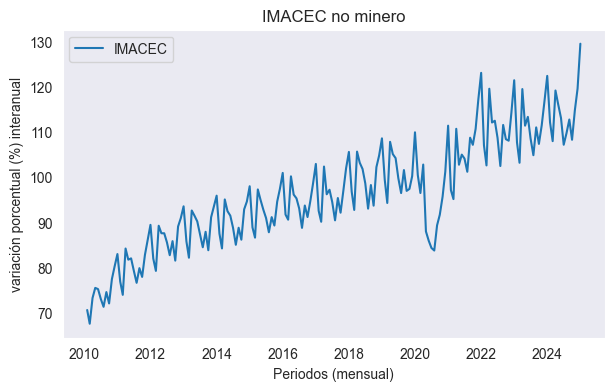

In [17]:
imacec_df = conn.cuadro(
    series = ['F032.IMC.IND.Z.Z.EP18.N03.Z.0.M'], # codigo relacionado al IMACEC no minero
    nombres = ["IMACEC"],
    desde = "2010-01-01",
    hasta = "2024-12-01",
    frecuencia = "ME",
    observado = "mean")

# Plot series de IMACEC no minero

plt.figure(figsize=(7,4))
sns.lineplot(data = imacec_df)
plt.xlabel('Periodos (mensual)')
plt.ylabel('variación porcentual (%) interanual')
plt.title('IMACEC no minero')
plt.show()

In [18]:
# Funcion que chequea si la serie es estacionaria
from statsmodels.tsa.stattools import adfuller

def valida_estacionariedad(serie, nivel_significancia = 0.05):

  # Aplica Test
  df_series = adfuller(serie)

  # Extrae Resultados
  estadistico_adf = df_series[0] # Estadistico del Test
  p_value = df_series[1]         # P-Valor
  lags_num = df_series[2]        # Rezagos
  o_obs = df_series[3]           # Num. Observaciones
  val_criticos = df_series[4]    # Valores Criticos

  # Determina si la serie es estacionaria
  es_estacionaria = p_value < nivel_significancia

  # Genera resumen de resultados
  resultado = {
      'Estadistico ADF': estadistico_adf,
      'P-Valor': p_value,
      'Rezagos': lags_num,
      'Num. Observaciones': o_obs,
      'valores criticos': val_criticos,
      'Es Estacionaria': es_estacionaria
  }

  # Muestra resultados
  print(f"Estadistico ADF: {estadistico_adf}")
  print(f"P-Valor: {p_value}")
  print(f"Numero de lags utilizados: {lags_num}")
  print(f"Numero de  Observaciones: {o_obs}")
  print(f"Valores Criticos: {val_criticos}")
  for clave, valor in val_criticos.items():
    print(f"  {clave}: {valor}")
  if es_estacionaria:
        print(f"La serie es estacionaria: {es_estacionaria}")
  else:
        print(f"La serie no es estacionaria: {es_estacionaria}")

  return resultado

valida_estacionariedad(imacec_df)

Estadistico ADF: -0.8353403087446362
P-Valor: 0.8085201166771672
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie no es estacionaria: False


{'Estadistico ADF': np.float64(-0.8353403087446362),
 'P-Valor': np.float64(0.8085201166771672),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.False_}

¿Qué puede decir respecto de la estacionariedad del IMACEC?

Se puede decir solo haciendo un análisis visual que es una serie de tiempo no estacionaria, se ve una tendencia al alza que se rompe el el año 2020 por lo efectos de la pandemia. Además bajo el análisis del test Dickey Fuller (ADF) la hipótesis nula es que la serie no es estacionaria, como muetra un pvalue mayor a 0.05 entonces no se rechaza por lo tanto es no estacionaria.

Presente las funciones de autocorrelación (con 24 rezagos) del IMACEC y de su primera diferencia. ¿Qué le sugieren estos resultados?. Justificar con cálculos del estadístico Ljung-Box.

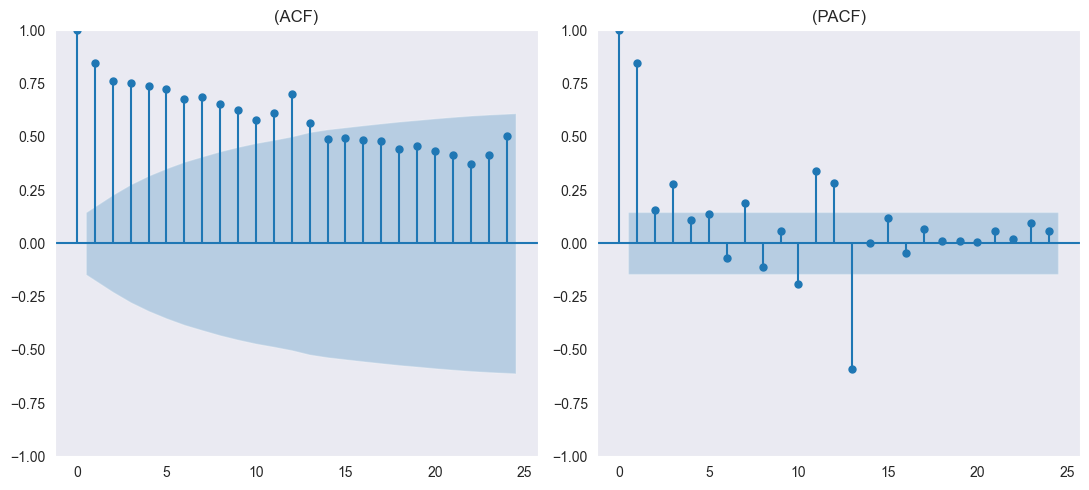

In [19]:
# Funcion que genera ACF y PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(serie, lags = None):

  # Configuro la figura a mostrar como subplots
  fig, axes = plt.subplots(1, 2, figsize=(11,5))

  # Grafico ACF
  plot_acf(serie, lags = lags, ax = axes[0], title = '(ACF)', zero = True)

  # Grafico PACF
  plot_pacf(serie, lags = lags, ax = axes[1], title = '(PACF)', zero = True)

  # Visualiza
  plt.tight_layout()
  plt.show()

# ACF y PACF Serie Imacec
plot_acf_pacf(imacec_df, lags = 24)

Las barras (autocorrelaciones) comienzan muy altas (cercanas a 1.0) y van bajando de forma muy gradual y lineal a medida que aumentan los rezagos, también casi todas se salen de la banda de confianza sombreada en azul. Por lo que los valores pasados siguen estando fuertemente correlacionados con el valor actual incluso muchos meses después.

Aplique el enfoque Box-Jenkins

In [63]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

# Rango de órdenes a probar
p_values = range(0, 4)  # AR
q_values = range(0, 4)  # MA

# Guardar resultados
resultados = []

for p in p_values:
    for q in q_values:
        if p == 0 and q == 0:
            continue  
        try:
            modelo = ARIMA(imacec_df, order = (p, 0, q), enforce_stationarity = False,
                           enforce_invertibility = False)
            resultado = modelo.fit()
            aic = resultado.aic
            bic = resultado.bic
            hqic = resultado.hqic
            
            resultados.append({
                'p': p,
                'q': q,
                'AIC': aic,
                'BIC': bic,
                'HQIC': hqic
            })
        except:
            continue  

resultados_df = pd.DataFrame(resultados).sort_values(by = 'AIC').reset_index(drop = True)
print(resultados_df.sort_values('BIC'))
warnings.simplefilter('ignore', ConvergenceWarning)

    p  q          AIC          BIC         HQIC
0   3  3  1058.993210  1084.357082  1069.280671
1   2  3  1077.845449  1100.038836  1086.846977
2   1  3  1081.060388  1100.083292  1088.775983
3   2  2  1081.347310  1100.404209  1089.076048
4   3  2  1083.250480  1105.483528  1092.267341
5   1  2  1091.867602  1107.748351  1098.308217
6   3  1  1096.497461  1115.554360  1104.226199
7   2  1  1105.375854  1121.284772  1111.827347
8   3  0  1107.449740  1123.330489  1113.890355
9   1  1  1113.387270  1126.114405  1118.548465
10  2  0  1133.286215  1146.013350  1138.447410
11  1  0  1144.992075  1154.554233  1148.869454
12  0  3  1178.342756  1194.195176  1184.772419
13  0  2  1220.948035  1233.652634  1226.100527
14  0  1  1243.669977  1253.215328  1247.540873


In [64]:
best_order_model = ARIMA(imacec_df, order = (2, 0, 3))
best_model_fit = best_order_model.fit()
best_model_fit.summary()


c:\Users\jeloy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\jeloy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                 IMACEC   No. Observations:                  180
Model:                 ARIMA(2, 0, 3)   Log Likelihood                -547.968
Date:                Wed, 01 Jul 2026   AIC                           1109.936
Time:                        23:51:09   BIC                           1132.287
Sample:                    01-31-2010   HQIC                          1118.999
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         96.2652     19.296      4.989      0.000      58.446     134.084
ar.L1          0.5281      0.248      2.133      0.033       0.043       1.013
ar.L2          0.4672      0.249      1.876      0.061      -0.021       0.955
ma.L1          0.1099      0.237      0.463      0.643      -0.355       0.575
ma.L2         -0.6550      0.090     -7.273      0.000      -0.832      -0.479
ma.L3          0.0028      0.143      0.020      0.984      -0.278       0.284
sigma2        25.2711      2.929      8.628      0.000      19.530      31.012
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 1.93
Prob(Q):                              0.73   Prob(JB):                         0.38
Heteroskedasticity (H):               2.38   Skew:                             0.23
Prob(H) (two-sided):                  0.00   Kurtosis:                         2.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [22]:
# almaceno resiudos del modelo arma(2,3)
residuos = best_model_fit.resid 

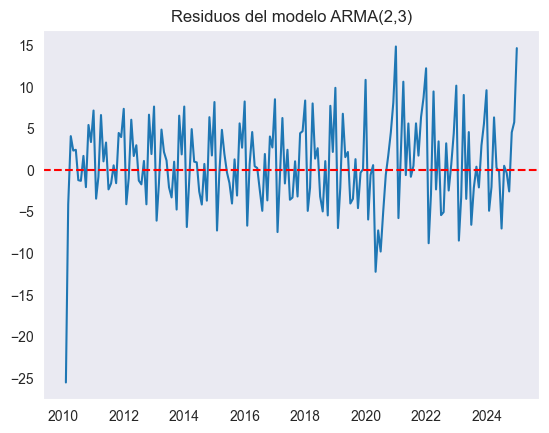

In [23]:
plt.plot(residuos)
plt.title("Residuos del modelo ARMA(2,3)")
plt.axhline(0, color = 'red', linestyle = '--')
plt.show()

In [24]:
valida_estacionariedad(residuos)

Estadistico ADF: -3.957604503731707
P-Valor: 0.0016495218571012057
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie es estacionaria: True


{'Estadistico ADF': np.float64(-3.957604503731707),
 'P-Valor': np.float64(0.0016495218571012057),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.True_}

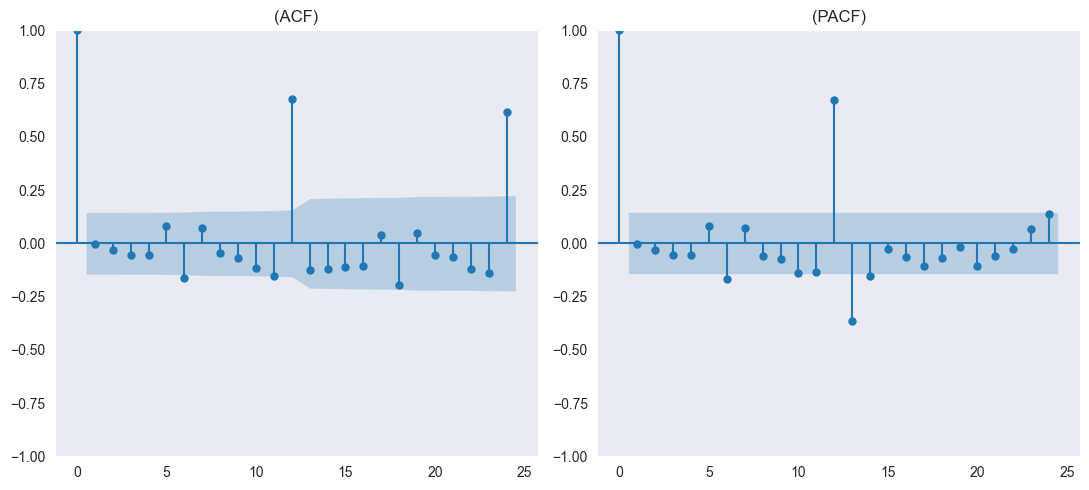

In [25]:
plot_acf_pacf(residuos, lags = 24)

In [26]:
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_result = acorr_ljungbox(residuos, lags = [10], return_df = True)
print(ljungbox_result)

      lb_stat  lb_pvalue
10  12.280278   0.266736


In [27]:
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuos)
print(f'Estadístico JB: {jb_stat:.2f}, p-valor: {jb_p:.4f}')

Estadístico JB: 49.45, p-valor: 0.0000


Esto es el reflejo matemático de la estacionalidad anual (12 meses) que veíamos visualmente en el gráfico del IMACEC. Lo que ocurre hoy está fuertemente influenciado por lo que ocurrió exactamente en el mismo mes del año anterior.

Con su mejor modelo, genere proyecciones para enero, febrero y marzo 2025, y compárelos con los reportes oficiales emitidos por el banco central en https://www.bcentral.cl/areas/estadisticas/imacec

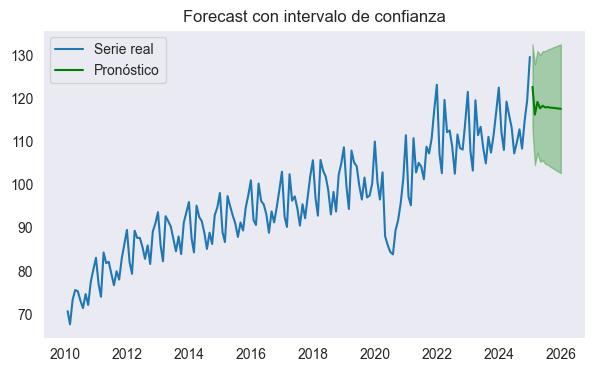

In [28]:
pred = best_model_fit.get_forecast(steps = 12)
media = pred.predicted_mean
conf_int = pred.conf_int()

# Visualizar con intervalos
plt.figure(figsize = (7, 4))
plt.plot(imacec_df, label='Serie real')
plt.plot(media, label='Pronóstico', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='green', alpha=0.3)
plt.title('Forecast con intervalo de confianza')
plt.legend()
plt.show()

Datos de Banco Central, Imacec No Minero 2025

Enero: 116,4
Febrero: 109,4
Marzo: 125,0	

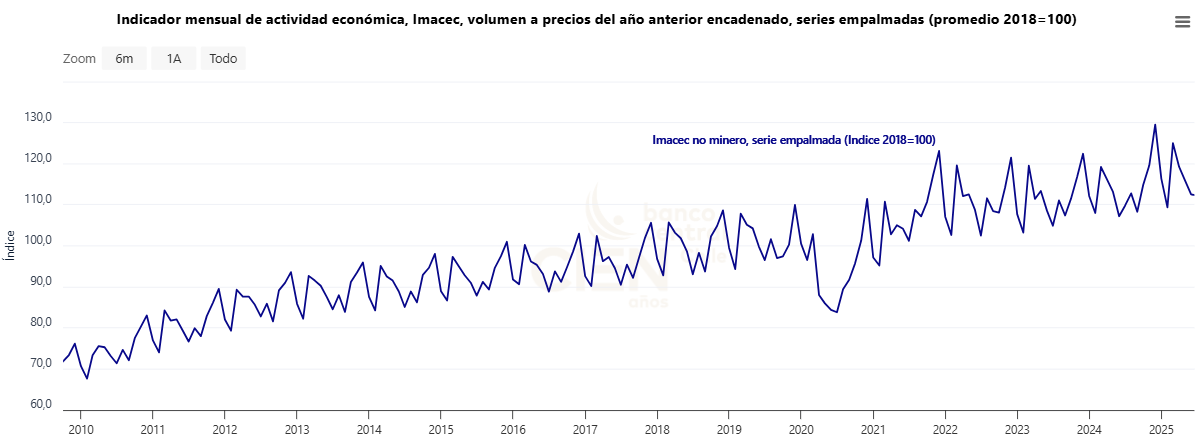

## 4. Inflación Chilena: Análisis Univariado de Series de Tiempo

La inflación es una variable central en la política monetaria chilena. En este ejercicio aplicará la metodología Box-Jenkins —vista en sesión 7— para modelar y pronosticar la inflación mensual en Chile, usando las mismas herramientas trabajadas en clases.

4.1 Datos desde la API del Banco Central
Usando bcchapi, descargue las siguientes series mensuales para el período enero 2010 – diciembre 2024:

| Variables | Código | Descripción |
|----------|--------|-------------|
| IPC | `G073.IPC.VAR.2023.M` | Variación mensual del IPC (base 2023=100) |
| TPM | `F022.TPM.TIN.D001.NO.ZD` | Tasa de Política Monetaria (%) |
| IMACEC | `F032.IMC.IND.ZZEP18.N03.Z.0.M` | IMACEC no minero (del Ejercicio 3) |

Calcule la inflación anual acumulada a 12 meses usando pct_change(12) sobre el índice de nivel del IPC (si lo descarga por separado) o bien sumando 12 variaciones mensuales consecutivas.

Grafique la inflación mensual y la anual en el mismo panel. Identifique visualmente: el efecto COVID-19 (2020) y el peak inflacionario (2021–2022).


In [66]:
# Descarga serie TPM

tpm_df = conn.cuadro(
    series = ['F022.TPM.TIN.D001.NO.Z.D'], # codigo relacionado a la TPM 
    nombres = ["tpm"],
    desde = "2010-01-01",
    hasta = "2024-12-31",
    frecuencia = "ME",
    observado = "mean")

tpm_df.head()

,tpm
2010-01-31,0.5
2010-02-28,0.5
2010-03-31,0.5
2010-04-30,0.5
2010-05-31,0.5


In [67]:
imacec_df2 = conn.cuadro(
    series = ['F032.IMC.IND.Z.Z.EP18.N03.Z.0.M'], # codigo relacionado al IMACEC no minero
    nombres = ["IMACEC"],
    desde = "2010-01-01",
    hasta = "2024-12-01",
    frecuencia = "ME",
    observado = "mean")

imacec_df2.head()

,IMACEC
2010-01-31,70.689670
2010-02-28,67.662023
2010-03-31,73.341273
2010-04-30,75.581962
2010-05-31,75.307518


In [29]:
# Descarga serie IPC

ipc_df = conn.cuadro(
    series = ['G073.IPC.VAR.2023.M'], # codigo relacionado al ipc 
    nombres = ["ipc"],
    desde = "2010-01-01",
    hasta = "2024-12-31",
    frecuencia = "ME",
    observado = "mean")

In [30]:
ipc_df.head()

,ipc
2010-01-31,0.518251
2010-02-28,0.280997
2010-03-31,0.084083
2010-04-30,0.462200
2010-05-31,0.359830


In [31]:
# Variación anual deL IPC

ipc_df['ipc_12m'] = (
    (1 + ipc_df['ipc']/100)
    .rolling(12)
    .apply(np.prod, raw=True)
    - 1
) * 100

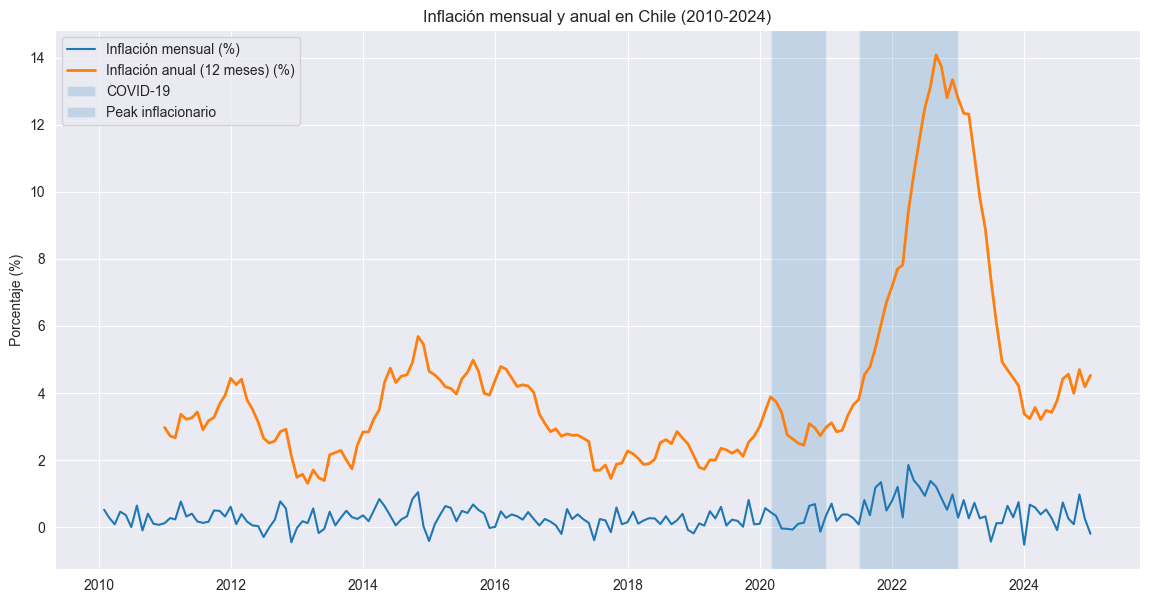

In [32]:
#Gráficos 
fig, ax = plt.subplots(figsize=(14,7))

ax.plot(
    ipc_df.index,
    ipc_df['ipc'],
    label='Inflación mensual (%)'
)

ax.plot(
    ipc_df.index,
    ipc_df['ipc_12m'],
    linewidth=2,
    label='Inflación anual (12 meses) (%)'
)

# Efecto COVID-19
ax.axvspan(
    pd.Timestamp('2020-03-01'),
    pd.Timestamp('2020-12-31'),
    alpha=0.2,
    label='COVID-19'
)

# Peak inflacionario
ax.axvspan(
    pd.Timestamp('2021-07-01'),
    pd.Timestamp('2022-12-31'),
    alpha=0.2,
    label='Peak inflacionario'
)

ax.set_title('Inflación mensual y anual en Chile (2010-2024)')
ax.set_ylabel('Porcentaje (%)')
ax.legend()
ax.grid(True)

plt.show()


## 4.2 Análisis de Estacionariedad
Trabaje con la serie de variación mensual del IPC ($\pi_t$):

1.Grafique la serie temporal.

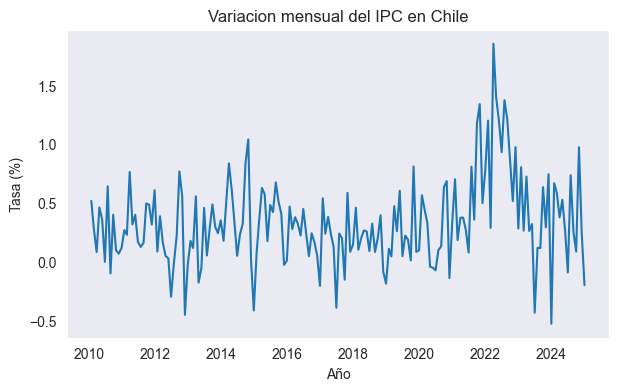

In [33]:
plt.figure(figsize = (7,4))
sns.lineplot(data = ipc_df['ipc'])
plt.xlabel('Año')
plt.ylabel('Tasa (%)')
plt.title('Variacion mensual del IPC en Chile')
plt.show()

2. Calcule y grafique la ACF y PACF con 24 rezagos. ¿Qué estructura sugieren los correlogramas?

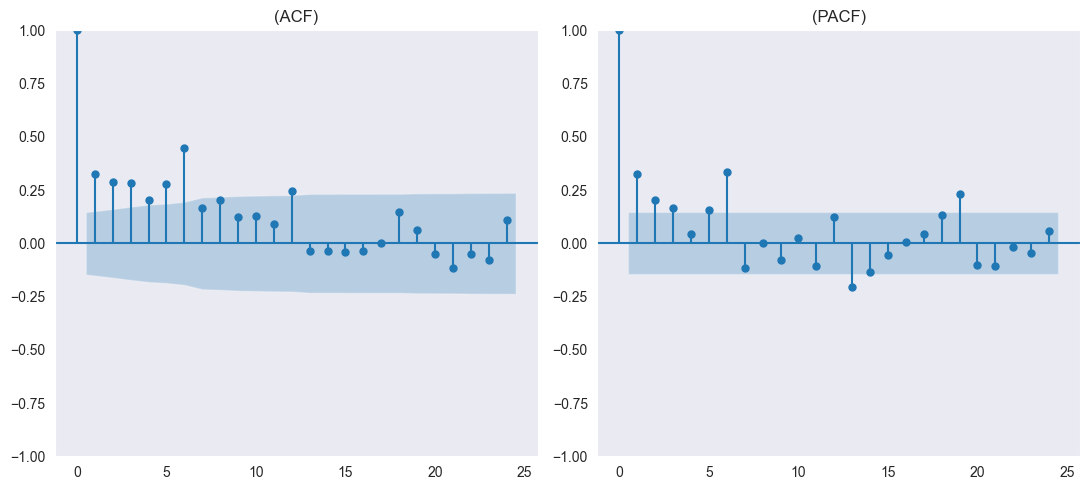

In [34]:
# Funcion que genera ACF y PACF

def plot_acf_pacf(serie, lags = None):

  # Configuro la figura a mostrar como subplots
  fig, axes = plt.subplots(1, 2, figsize=(11,5))

  # Grafico ACF
  plot_acf(serie, lags = lags, ax = axes[0], title = '(ACF)', zero = True)

  # Grafico PACF
  plot_pacf(serie, lags = lags, ax = axes[1], title = '(PACF)', zero = True)

  # Visualiza
  plt.tight_layout()
  plt.show()

# ACF y PACF Serie Imacec
plot_acf_pacf(ipc_df['ipc'], lags = 24)

Los correlogramas sugieren que los rezagos caen de forma exponencial, en la función ACF los rezagos 2 al 5 muestra un patrón de decrecimiento y en el PACF luego los rezagos 2, 3, 4 se van reduciendo o entran dentro de las bandas.

2. Aplique el test ADF. Reporte estadístico, p-value y valores críticos. ¿Es la serie estacionaria?

In [35]:
# Funcion que chequea si la serie es estacionaria
from statsmodels.tsa.stattools import adfuller

def valida_estacionariedad(serie, nivel_significancia = 0.05):

  # Aplica Test
  df_series = adfuller(serie)

  # Extrae Resultados
  estadistico_adf = df_series[0] # Estadistico del Test
  p_value = df_series[1]         # P-Valor
  lags_num = df_series[2]        # Rezagos
  o_obs = df_series[3]           # Num. Observaciones
  val_criticos = df_series[4]    # Valores Criticos

  # Determina si la serie es estacionaria
  es_estacionaria = p_value < nivel_significancia

  # Genera resumen de resultados
  resultado = {
      'Estadistico ADF': estadistico_adf,
      'P-Valor': p_value,
      'Rezagos': lags_num,
      'Num. Observaciones': o_obs,
      'valores criticos': val_criticos,
      'Es Estacionaria': es_estacionaria
  }

  # Muestra resultados
  print(f"Estadistico ADF: {estadistico_adf}")
  print(f"P-Valor: {p_value}")
  print(f"Numero de lags utilizados: {lags_num}")
  print(f"Numero de  Observaciones: {o_obs}")
  print(f"Valores Criticos: {val_criticos}")
  for clave, valor in val_criticos.items():
    print(f"  {clave}: {valor}")
  if es_estacionaria:
        print(f"La serie es estacionaria: {es_estacionaria}")
  else:
        print(f"La serie no es estacionaria: {es_estacionaria}")

  return resultado

valida_estacionariedad(ipc_df['ipc'])

Estadistico ADF: -3.1547052529107544
P-Valor: 0.022760835121932246
Numero de lags utilizados: 13
Numero de  Observaciones: 166
Valores Criticos: {'1%': np.float64(-3.4703698981001665), '5%': np.float64(-2.8791138497902193), '10%': np.float64(-2.576139407751488)}
  1%: -3.4703698981001665
  5%: -2.8791138497902193
  10%: -2.576139407751488
La serie es estacionaria: True


{'Estadistico ADF': np.float64(-3.1547052529107544),
 'P-Valor': np.float64(0.022760835121932246),
 'Rezagos': 13,
 'Num. Observaciones': 166,
 'valores criticos': {'1%': np.float64(-3.4703698981001665),
  '5%': np.float64(-2.8791138497902193),
  '10%': np.float64(-2.576139407751488)},
 'Es Estacionaria': np.True_}

Según el test Dickey Fuller (ADF) la hipótesis nula es que la serie no es estacionaria, como muetra un pvalue menor a 0.05 (0.022) entonces se rechaza la hipótesis por lo tanto la serie es estacionaria.

Aplique la descomposición estacional (seasonal_decompose, periodo = 12). ¿Existe componente estacional significativa?

<Figure size 1400x1000 with 0 Axes>

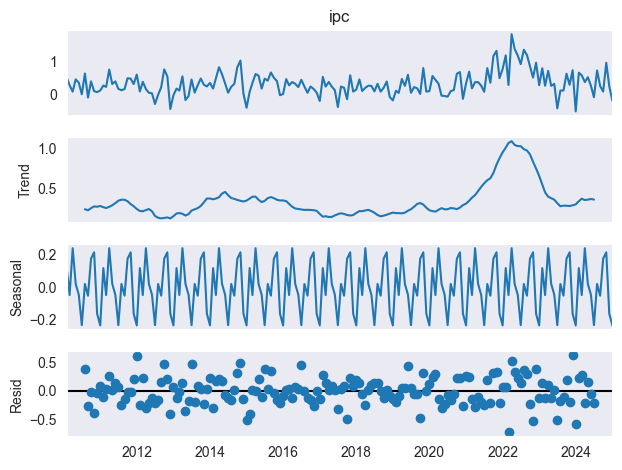

In [36]:
# Descomposición de la serie de tiempo
decomposition = sm.tsa.seasonal_decompose(ipc_df['ipc'], model = 'additive', period = 12)

# Visualizar la descomposición
plt.figure(figsize=(14, 10))
decomposition.plot()
plt.show()

Se puede observar que existe una componente estacional muy claro.

5. Aplique el filtro de Hodrick-Prescott con $\lambda = 14400$ para datos mensuales. Grafique la serie original vs. tendencia estimada.

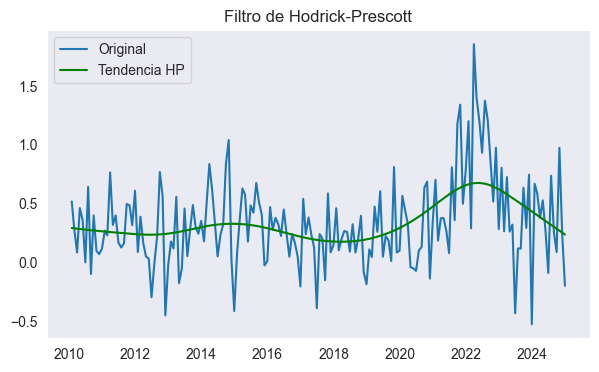

In [37]:
from statsmodels.tsa.filters.hp_filter import hpfilter

ciclo, tendencia = hpfilter(ipc_df['ipc'], lamb = 14400)

# Graficar
plt.figure(figsize = (7,4))
plt.plot(ipc_df['ipc'], label = 'Original')
plt.plot(tendencia, label = 'Tendencia HP', color = 'green')
plt.legend()
plt.title("Filtro de Hodrick-Prescott")
plt.show()

6. Si detecta estacionalidad, trabaje con la serie desestacionalizada en los pasos siguientes.

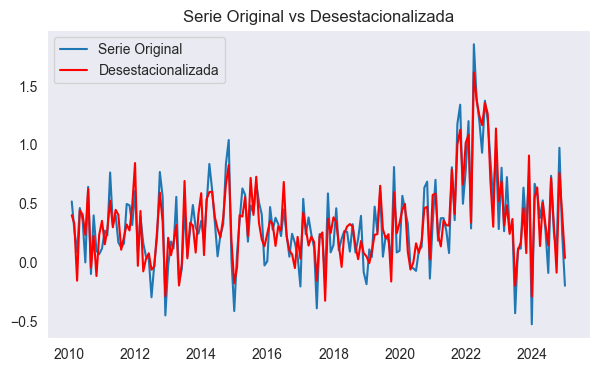

In [38]:
# remover estacionalidad del ipc 
serie_desestacionalizada = ipc_df['ipc'] - decomposition.seasonal

plt.figure(figsize = (7,4))
plt.plot(ipc_df['ipc'], label = 'Serie Original')
plt.plot(serie_desestacionalizada, label = 'Desestacionalizada', color = 'red')
plt.legend()
plt.title('Serie Original vs Desestacionalizada')
plt.show()

## 4.3 Selección del Modelo: Grilla AIC/BIC

Estime por grilla modelos **ARMA($p$,$q$)** con $p \in \{0,1,2,3\}$ y $q \in \{0,1,2,3\}$ usando `statsmodels.tsa.arima.model.ARIMA`.

In [39]:
from statsmodels.tsa.arima.model import ARIMA

# Rango de órdenes a probar
p_values = range(0, 4)  # AR
q_values = range(0, 4)  # MA

# Guardar resultados
resultados = []

for p in p_values:
    for q in q_values:
        if p == 0 and q == 0:
            continue  # no tiene sentido un modelo ARMA(0, 0)
        try:
            modelo = ARIMA(serie_desestacionalizada, order = (p, 0, q), enforce_stationarity = False,
                           enforce_invertibility = False)
            resultado = modelo.fit()
            aic = resultado.aic
            bic = resultado.bic
            hqic = resultado.hqic
            
            resultados.append({
                'p': p,
                'q': q,
                'AIC': aic,
                'BIC': bic,
                'HQIC': hqic
            })
        except:
            continue  # si falla, lo ignora


In [40]:
resultados_df = pd.DataFrame(resultados).sort_values(by = 'AIC').reset_index(drop = True)
print(resultados_df.sort_values('BIC'))

    p  q        AIC         BIC        HQIC
3   1  1  60.928421   73.655555   66.089616
0   3  0  58.292517   74.173266   64.733132
5   2  1  61.541841   77.450759   67.993334
6   1  2  61.871100   77.751848   68.311714
2   3  1  60.262399   79.319297   67.991136
4   1  3  61.442354   80.465258   69.157949
8   2  2  63.440744   82.497642   71.169482
10  2  0  71.424322   84.151456   76.585516
7   3  2  61.966099   84.199147   70.982960
1   3  3  59.412831   84.776703   69.700292
9   2  3  66.583737   88.777124   75.585265
11  0  3  75.041452   90.893872   81.471115
12  1  0  85.356758   94.918916   89.234137
13  0  2  85.911666   98.616265   91.064158
14  0  1  97.413914  106.959265  101.284810


Seleccione el mejor modelo. ¿Coinciden AIC y BIC? ¿Qué criterio prefiere y por qué?

El modelo a elegir es el ARMA (2,1), si bien no coinciden los valores AIC y BIC, ya que EL AIC favorece el modelo (3,0) y el BIC favorece el modelo (1.1), pero ninguno de esos modelos pasa el test de Ljung-Box, indicando que los residuos aún presentan autocorrelación, por lo que es apropiado elegir el modelo con el menor BIC que pueda pasar el test de Ljung-Box, en este caso el modelo (2,1).

4. Reporte los coeficientes estimados del modelo seleccionado con errores estándar y p-values. ¿Son todos significativos?

In [41]:
mejor_orden_modelo = ARIMA(serie_desestacionalizada, order = (2, 0, 1))
mejor_modelo_fit = mejor_orden_modelo.fit()
mejor_modelo_fit.summary()

c:\Users\jeloy\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  180
Model:                 ARIMA(2, 0, 1)   Log Likelihood                 -25.339
Date:                Wed, 01 Jul 2026   AIC                             60.678
Time:                        22:42:40   BIC                             76.643
Sample:                    01-31-2010   HQIC                            67.151
                         - 12-31-2024                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.3306      0.084      3.922      0.000       0.165       0.496
ar.L1          0.7884      0.135      5.819      0.000       0.523       1.054
ar.L2          0.1088      0.095      1.143      0.253      -0.078       0.295
ma.L1         -0.6034      0.133     -4.554      0.000      -0.863      -0.344
sigma2         0.0773      0.008      9.606      0.000       0.062       0.093
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.02
Prob(Q):                              0.97   Prob(JB):                         0.60
Heteroskedasticity (H):               1.63   Skew:                             0.17
Prob(H) (two-sided):                  0.06   Kurtosis:                         3.15
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

El resumen estadístico del modelo muestra errores estándar y valores p value son bajos.

## 4.4 Diagnóstico del Modelo

Para los residuos del modelo seleccionado:

Grafique los residuos en el tiempo. ¿Se comportan como ruido blanco?

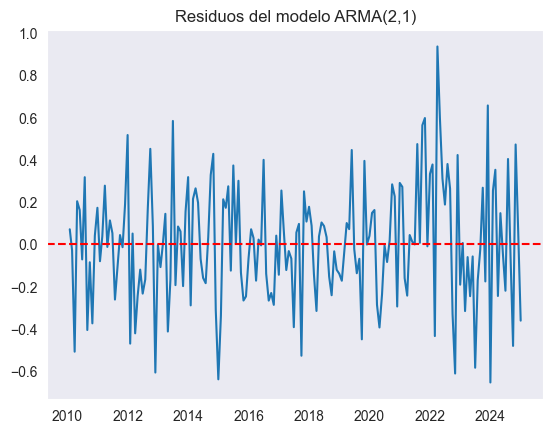

In [42]:
# almaceno resiudos del modelo arma(2,1)
residuos_ipc = mejor_modelo_fit.resid 

plt.plot(residuos_ipc)
plt.title("Residuos del modelo ARMA(2,1)")
plt.axhline(0, color = 'red', linestyle = '--')
plt.show()

Los residuos se observan que están fluctuando el valor cero, por lo que si se comportan como ruido blanco.

2.Grafique ACF y PACF de los residuos (24 rezagos).

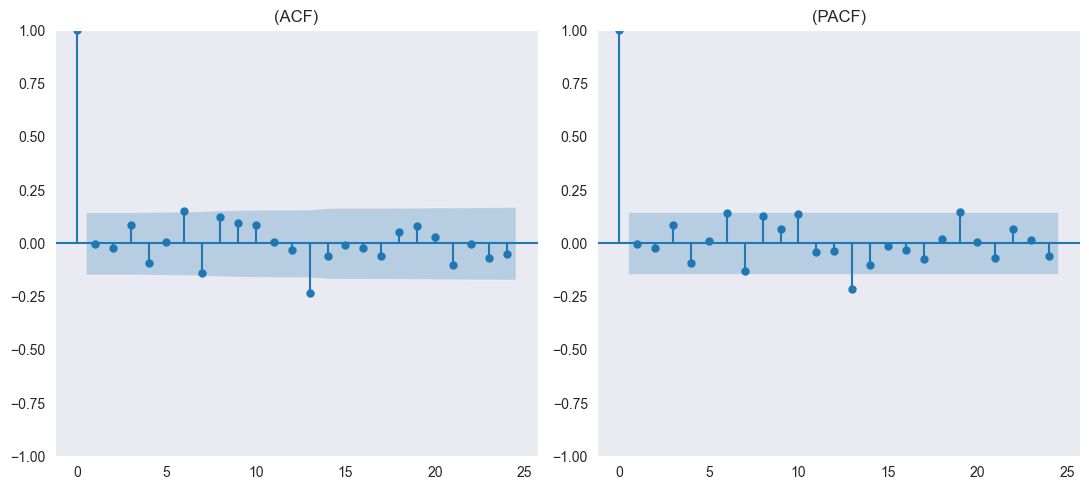

In [43]:
# Funcion que genera ACF y PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

def plot_acf_pacf(serie, lags = None):

  # Configuro la figura a mostrar como subplots
  fig, axes = plt.subplots(1, 2, figsize=(11,5))

  # Grafico ACF
  plot_acf(serie, lags = lags, ax = axes[0], title = '(ACF)', zero = True)

  # Grafico PACF
  plot_pacf(serie, lags = lags, ax = axes[1], title = '(PACF)', zero = True)

  # Visualiza
  plt.tight_layout()
  plt.show()

# ACF y PACF Serie Imacec
plot_acf_pacf(residuos_ipc, lags = 24)

Aplique el **test de Ljung-Box** con $k = 10$ y $k = 20$ rezagos. Reporte estadístico y $p$-value. ¿Se rechaza $H_0$?

In [44]:
#Test de Ljung-Box con k = 10
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_result = acorr_ljungbox(residuos_ipc, lags = [10], return_df = True)
print(ljungbox_result)

#Test de Ljung-Box con k = 20
from statsmodels.stats.diagnostic import acorr_ljungbox
ljungbox_result = acorr_ljungbox(residuos_ipc, lags = [20], return_df = True)
print(ljungbox_result)


     lb_stat  lb_pvalue
10  17.02231   0.073872
      lb_stat  lb_pvalue
20  31.397173   0.050161


Como el p-value es mayor a 0,05 no se rechaza la hipótesis nula, entonces no hay evidencia de autocorrelación de los residuos, son independientes.

4. Evalúe normalidad: histograma con KDE, Q-Q plot y test de Jarque-Bera.

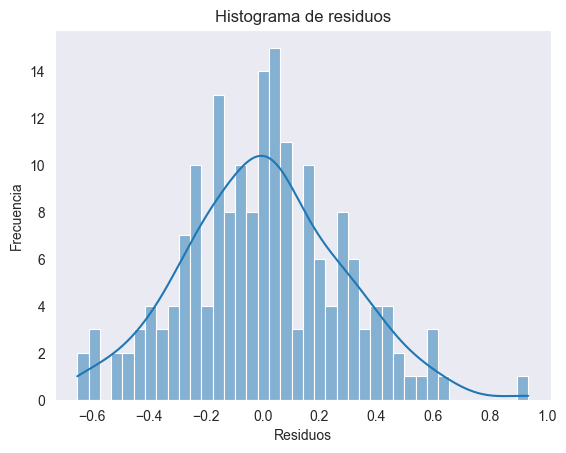

In [45]:
#Histograma
sns.histplot(residuos_ipc, bins = 40, kde = True)
plt.title("Histograma de residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

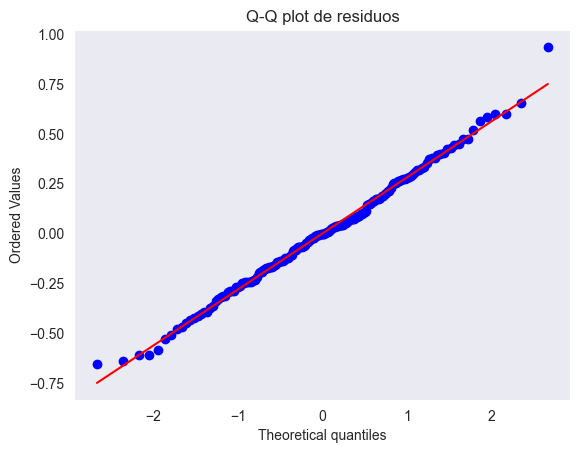

In [46]:
import scipy.stats as stats
stats.probplot(residuos_ipc, dist="norm", plot=plt)
plt.title("Q-Q plot de residuos")
plt.show()

In [47]:
#Test de Jarque-Bera

from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuos_ipc)   
print(f'Estadístico JB: {jb_stat:.2f}, p-valor: {jb_p:.4f}')

Estadístico JB: 1.00, p-valor: 0.6078


6.¿Su modelo pasa todos los diagnósticos? Si no, ¿qué ajuste realizaría?

El modelo (2,1) si pasa el diagnóstico de los residuos son estacionarios, independientes (test de Ljung-Box) y se distribuyen con normalidad.

De lo contratio, se debe buscar otro modelo ARMA (p,q) que tenga un buen ajuste (AIC/BIC bajos) y con residuos que superen los diagnósticos.

## 4.5 Proyecciones

1. Genere proyecciones para enero, febrero y marzo 2025 con intervalos de confianza al 95%.

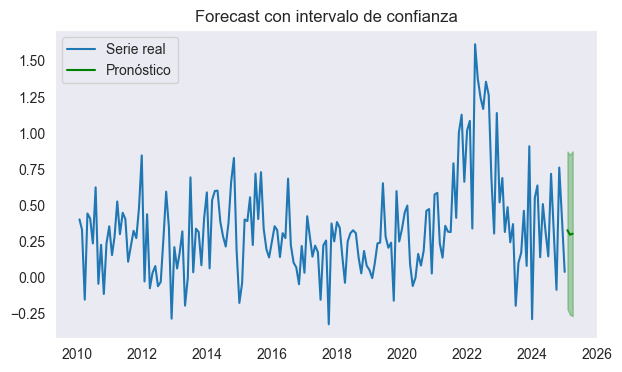

In [48]:
pred = mejor_modelo_fit.get_forecast(steps = 3)
media = pred.predicted_mean
conf_int = pred.conf_int()

# Visualizar con intervalos
plt.figure(figsize = (7, 4))
plt.plot(serie_desestacionalizada, label='Serie real')
plt.plot(media, label='Pronóstico', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:,0], conf_int.iloc[:,1], color='green', alpha=0.3)
plt.title('Forecast con intervalo de confianza')
plt.legend()
plt.show()

In [49]:
# Crear DataFrame del pronóstico

#Valores Reales IPC
ipc_reales = [1.1, 0.4, 0.5 ]

forecast_df = pd.DataFrame({
    'Fecha': media.index,
    'Proyección': media.values,
    'IC Inferior': conf_int.iloc[:, 0].values,
    'IC Superior': conf_int.iloc[:, 1].values,
    'IPC efectivo': ipc_reales,
    'Error': ipc_reales - media.values
})

# Establecer la columna 'Fecha' como índice (opcional)
forecast_df.set_index('Fecha', inplace = True)

# Mostrar
forecast_df

,Proyección,IC Inferior,IC Superior,IPC efectivo,Error
Fecha,,,,,
2025-01-31,0.326296,-0.218804,0.871396,1.1,0.773704
2025-02-28,0.295314,-0.259039,0.849668,0.4,0.104686
2025-03-31,0.302317,-0.269158,0.873792,0.5,0.197683


2.Compare con los valores efectivos del IPC reportados por el Banco Central.

El valor para enero fue el que más diferencias tuvo ya que en la relaidad mostró una variación del IPC superior al 1%, la comparación de febrero y marzo estuvo más cerca de los valores reales.

3.Calcule el RMSE y MAE sobre los 3 meses proyectados.

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Extraer variables del DataFrame
reales = ipc_reales
proyecciones = forecast_df['Proyección']

# Calcular MAE (Error Absoluto Medio)
mae = mean_absolute_error(reales, proyecciones)

# Calcular RMSE (Raíz del Error Cuadrático Medio)
rmse = np.sqrt(mean_squared_error(reales, proyecciones))

print(f"MAE sobre los 3 meses proyectados: {mae:.4f}")
print(f"RMSE sobre los 3 meses proyectados: {rmse:.4f}")

MAE sobre los 3 meses proyectados: 0.3587
RMSE sobre los 3 meses proyectados: 0.4650
